# Topic 4: Regularization
### DS + MLE Interview Study Plan — Theory Notebook

---

## Section 1: The core idea

Your model has a job: learn patterns from training data that generalize to new data. But there's a tension:

- **Too simple** → misses real patterns (underfitting, high bias)
- **Too flexible** → memorizes noise as if it were signal (overfitting, high variance)

Regularization tells the model: *"stay simple unless the data really justifies complexity."*

The mechanism:

$$\text{Optimize: } \text{Loss} + \lambda \cdot \text{Complexity Penalty}$$

Without regularization, the model just minimizes loss — it'll contort itself to fit every training point. With regularization, every bit of complexity costs something. The model only "buys" complexity when it reduces loss enough to justify the price.

**λ is the price tag.** Higher λ = simpler model. Lower λ = more flexible model.


## Section 2: L1 vs L2 — the two flavors

Both penalize large weights, but they do it differently, and that difference matters.

### L2 (Ridge): penalty = λ × Σ wⱼ²

Squaring means the penalty grows **quadratically**. A weight of 4 is penalized 16× more than a weight of 1.

**Effect:** every weight gets pulled toward zero, but nothing reaches exactly zero. Big weights shrink a lot, small weights barely shrink.

**Use when:** you want to keep all features but use them cautiously. Default choice.

### L1 (Lasso): penalty = λ × Σ |wⱼ|

Absolute value means the penalty grows **linearly**. A weight of 4 is penalized only 4× more than a weight of 1.

**Effect:** L1 pushes weights to **exactly zero**. Automatic feature selection — weak features get dropped entirely.

**Use when:** you have many features and want the model to pick the important ones.

### The geometric intuition

L2 creates a **circular** constraint region. L1 creates a **diamond** with sharp corners on the axes. When optimization touches a corner, that weight becomes exactly zero.

### Same idea, different names

| Model | L2 form | L1 form |
|-------|---------|---------|
| Linear regression | Ridge | Lasso |
| Logistic regression | L2 logistic | L1 logistic |
| XGBoost | `reg_lambda` (shrinks leaves) | `reg_alpha` |
| Neural networks | Weight decay | Less common |

You already saw λ in XGBoost — it shrank leaf values via the denominator of $w^* = -G/(H+\lambda)$. Same concept.


## Section 3: The bias-variance tradeoff

This is the conceptual home of regularization.

Every prediction error decomposes into:
- **Bias:** how wrong your model is on average (rigid model, can't capture the pattern)
- **Variance:** how much your model swings between training runs (flexible model, fits noise differently each time)
- **Irreducible error:** noise you can never beat

Regularization is a knob that trades variance for bias.

As λ increases:
- Variance **drops** (model becomes more stable, less sensitive to training data)
- Bias **rises** (model gets simpler, may miss real patterns)
- Total error has a **U-shape** — there's an optimal λ

You find that optimal λ with cross-validation: try a grid of λ values, pick the one with the lowest validation error.


## Section 4: See it in action

Let's build a polynomial regression problem and watch regularization work.


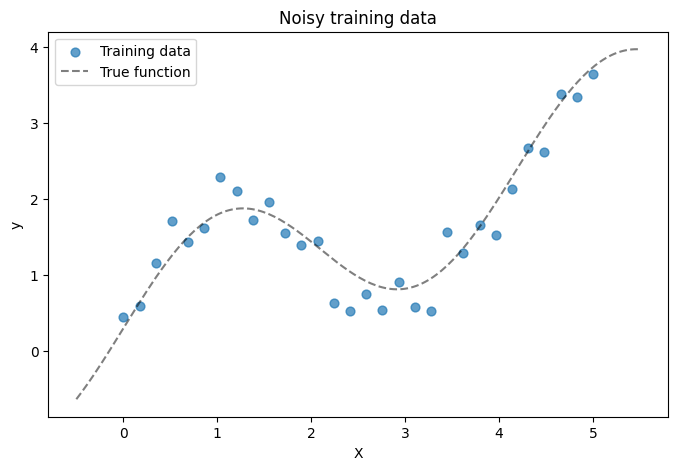

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Generate noisy data — true relationship is a smooth curve
def true_function(x):
    return 0.5 * x + np.sin(x * 1.5) + 0.3

n = 30
X = np.linspace(0, 5, n).reshape(-1, 1)
y = true_function(X.ravel()) + np.random.normal(0, 0.3, n)

X_plot = np.linspace(-0.5, 5.5, 200).reshape(-1, 1)
y_true_plot = true_function(X_plot.ravel())

plt.figure(figsize=(8, 5))
plt.scatter(X, y, alpha=0.7, s=40, label='Training data')
plt.plot(X_plot, y_true_plot, 'k--', alpha=0.5, label='True function')
plt.xlabel('X'); plt.ylabel('y')
plt.title('Noisy training data')
plt.legend()
plt.show()


### Experiment 1: Watch regularization fight overfitting

We'll fit a 15th-degree polynomial — way too flexible for this data. Then watch what happens as we increase λ.


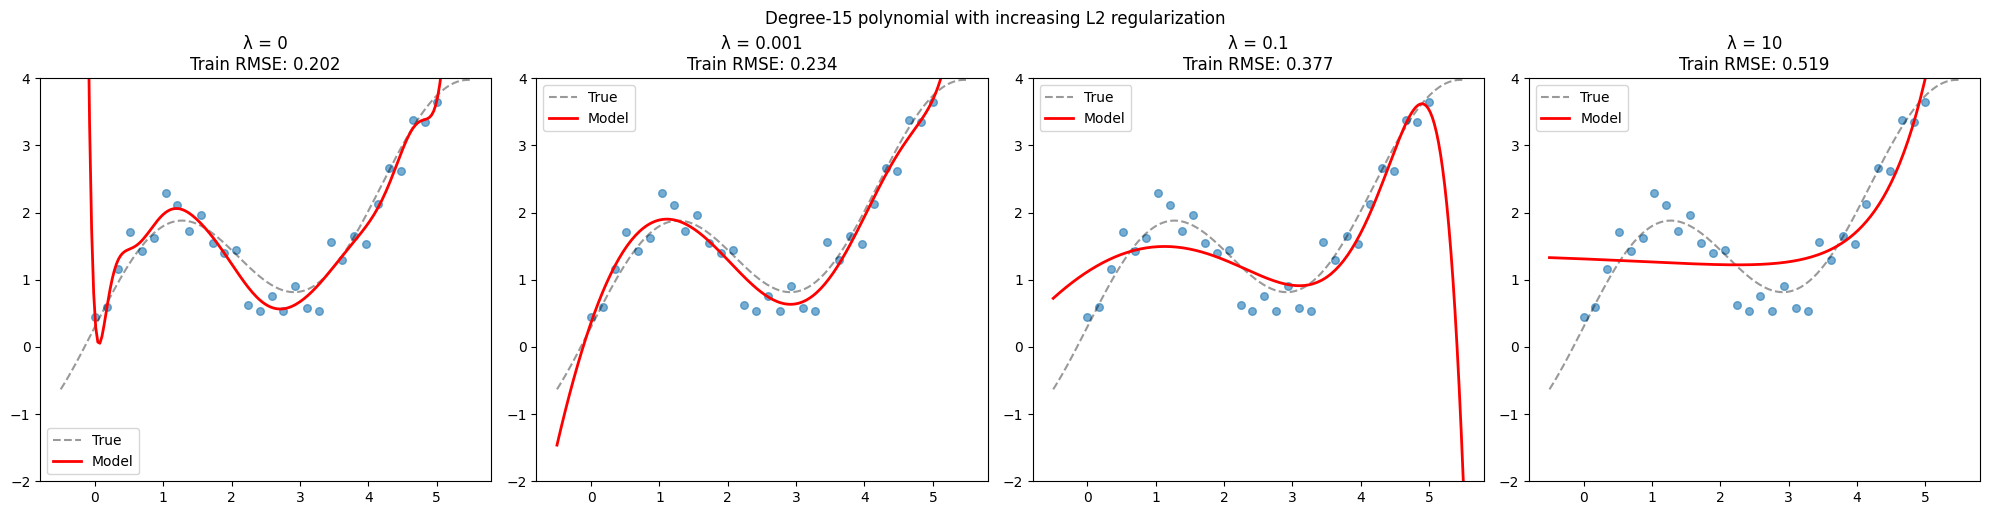

Observations:
  λ = 0:     model wiggles wildly through every point (overfit)
  λ = 0.001: still erratic, but smoother
  λ = 0.1:   close to the true function (sweet spot)
  λ = 10:    too smooth, missing real patterns (underfit)


In [2]:
def make_poly_pipeline(degree, alpha=0, model_type='ridge'):
    if alpha == 0:
        regressor = LinearRegression()
    elif model_type == 'ridge':
        regressor = Ridge(alpha=alpha)
    else:
        regressor = Lasso(alpha=alpha, max_iter=10000)
    return Pipeline([
        ('poly', PolynomialFeatures(degree=degree, include_bias=False)),
        ('scaler', StandardScaler()),
        ('reg', regressor)
    ])

# 15th-degree polynomial with varying lambda (alpha in sklearn)
lambdas = [0, 0.001, 0.1, 10]
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for ax, lam in zip(axes, lambdas):
    model = make_poly_pipeline(degree=15, alpha=lam, model_type='ridge')
    model.fit(X, y)
    y_pred_plot = model.predict(X_plot)
    train_rmse = np.sqrt(mean_squared_error(y, model.predict(X)))
    
    ax.scatter(X, y, alpha=0.6, s=30)
    ax.plot(X_plot, y_true_plot, 'k--', alpha=0.4, label='True')
    ax.plot(X_plot, y_pred_plot, 'r-', linewidth=2, label='Model')
    ax.set_title(f'λ = {lam}\nTrain RMSE: {train_rmse:.3f}')
    ax.set_ylim(-2, 4)
    ax.legend()

plt.tight_layout()
plt.suptitle('Degree-15 polynomial with increasing L2 regularization', y=1.02)
plt.show()

print("Observations:")
print("  λ = 0:     model wiggles wildly through every point (overfit)")
print("  λ = 0.001: still erratic, but smoother")
print("  λ = 0.1:   close to the true function (sweet spot)")
print("  λ = 10:    too smooth, missing real patterns (underfit)")


### Experiment 2: L1 vs L2 — feature selection in action

L1 zeros out weights. L2 shrinks them. Let's see this directly with weight values.


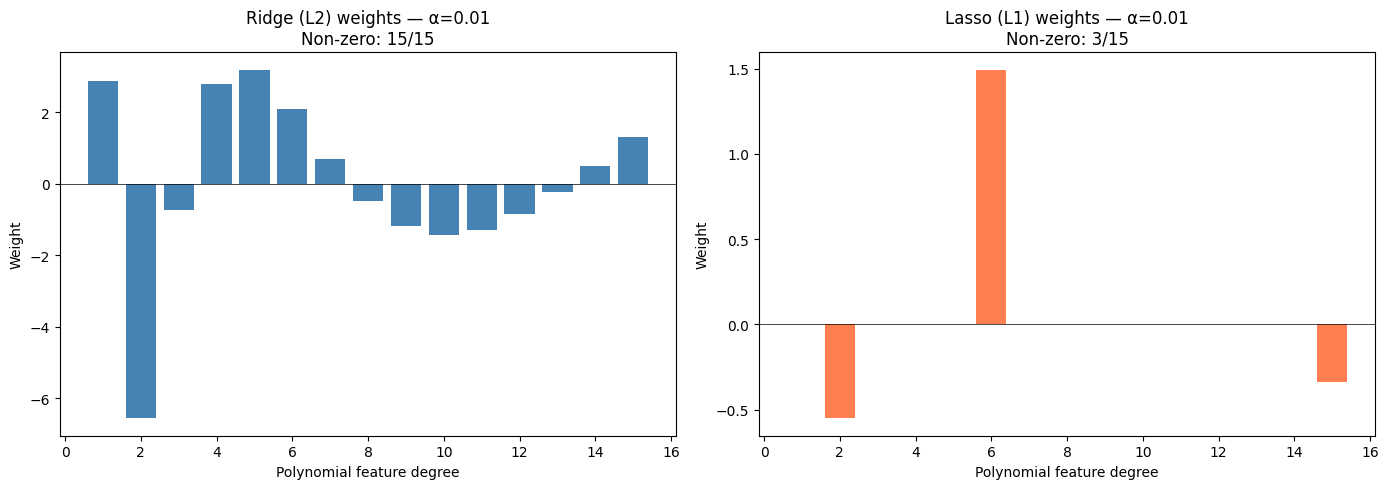

Ridge: kept all 15 features (all weights are nonzero, just shrunken)
Lasso: zeroed out most features, kept only the ones that matter

This is the practical difference:
  Ridge = 'use everything, just be cautious'
  Lasso = 'pick the few features that matter, drop the rest'


In [3]:
# Use a degree-15 polynomial → 15 features
# Compare L1 and L2 weight patterns
degree = 15
alpha = 0.01

ridge_model = make_poly_pipeline(degree=degree, alpha=alpha, model_type='ridge')
ridge_model.fit(X, y)
ridge_weights = ridge_model.named_steps['reg'].coef_

lasso_model = make_poly_pipeline(degree=degree, alpha=alpha, model_type='lasso')
lasso_model.fit(X, y)
lasso_weights = lasso_model.named_steps['reg'].coef_

# Side-by-side bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
feature_idx = np.arange(1, degree + 1)

axes[0].bar(feature_idx, ridge_weights, color='steelblue')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].set_title(f'Ridge (L2) weights — α={alpha}\nNon-zero: {np.sum(np.abs(ridge_weights) > 1e-4)}/{degree}')
axes[0].set_xlabel('Polynomial feature degree')
axes[0].set_ylabel('Weight')

axes[1].bar(feature_idx, lasso_weights, color='coral')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_title(f'Lasso (L1) weights — α={alpha}\nNon-zero: {np.sum(np.abs(lasso_weights) > 1e-4)}/{degree}')
axes[1].set_xlabel('Polynomial feature degree')
axes[1].set_ylabel('Weight')

plt.tight_layout()
plt.show()

print(f"Ridge: kept all {degree} features (all weights are nonzero, just shrunken)")
print(f"Lasso: zeroed out most features, kept only the ones that matter")
print()
print("This is the practical difference:")
print("  Ridge = 'use everything, just be cautious'")
print("  Lasso = 'pick the few features that matter, drop the rest'")


### Experiment 3: The bias-variance U-curve

Try many λ values. Plot train error and validation error vs λ. You'll see the classic U-shape.


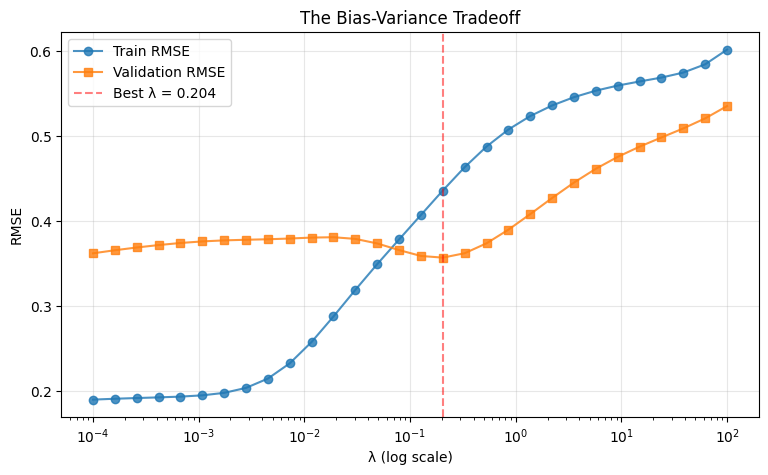

Reading this chart:
  LEFT side (small λ):  Train error low, Val error high → OVERFITTING
    Model is too flexible, memorizing noise.

  RIGHT side (large λ): Both errors high → UNDERFITTING
    Model is too constrained, can't capture real patterns.

  SWEET SPOT (λ ≈ 0.204): Validation error is minimized.
    This is what cross-validation finds for you automatically.


In [4]:
# Split into train and validation
X_tr, X_val, y_tr, y_val = train_test_split(X, y, test_size=0.3, random_state=1)

lambdas = np.logspace(-4, 2, 30)
train_errors = []
val_errors = []

for lam in lambdas:
    model = make_poly_pipeline(degree=15, alpha=lam, model_type='ridge')
    model.fit(X_tr, y_tr)
    train_errors.append(np.sqrt(mean_squared_error(y_tr, model.predict(X_tr))))
    val_errors.append(np.sqrt(mean_squared_error(y_val, model.predict(X_val))))

best_idx = np.argmin(val_errors)
best_lambda = lambdas[best_idx]

plt.figure(figsize=(9, 5))
plt.semilogx(lambdas, train_errors, 'o-', label='Train RMSE', alpha=0.8)
plt.semilogx(lambdas, val_errors, 's-', label='Validation RMSE', alpha=0.8)
plt.axvline(best_lambda, color='red', linestyle='--', alpha=0.5, 
            label=f'Best λ = {best_lambda:.3f}')
plt.xlabel('λ (log scale)')
plt.ylabel('RMSE')
plt.title('The Bias-Variance Tradeoff')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("Reading this chart:")
print("  LEFT side (small λ):  Train error low, Val error high → OVERFITTING")
print("    Model is too flexible, memorizing noise.")
print()
print("  RIGHT side (large λ): Both errors high → UNDERFITTING")  
print("    Model is too constrained, can't capture real patterns.")
print()
print(f"  SWEET SPOT (λ ≈ {best_lambda:.3f}): Validation error is minimized.")
print("    This is what cross-validation finds for you automatically.")


### Experiment 4: Use cross-validation to pick λ automatically

In real work, you don't pick λ by hand. RidgeCV and LassoCV try many values and pick the best one.


In [5]:
# RidgeCV with built-in cross-validation
ridge_cv = Pipeline([
    ('poly', PolynomialFeatures(degree=15, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', RidgeCV(alphas=np.logspace(-4, 2, 50), cv=5))
])
ridge_cv.fit(X, y)
best_alpha_ridge = ridge_cv.named_steps['reg'].alpha_

lasso_cv = Pipeline([
    ('poly', PolynomialFeatures(degree=15, include_bias=False)),
    ('scaler', StandardScaler()),
    ('reg', LassoCV(alphas=np.logspace(-4, 2, 50), cv=5, max_iter=10000))
])
lasso_cv.fit(X, y)
best_alpha_lasso = lasso_cv.named_steps['reg'].alpha_

print(f"Ridge CV picked α = {best_alpha_ridge:.4f}")
print(f"Lasso CV picked α = {best_alpha_lasso:.4f}")
print()
print("In practice, you almost always use CV variants. They:")
print("  1. Try many λ values")
print("  2. Score each one via cross-validation")
print("  3. Return the model trained with the best λ")
print("  All in one .fit() call.")


Ridge CV picked α = 2.5595
Lasso CV picked α = 0.0121

In practice, you almost always use CV variants. They:
  1. Try many λ values
  2. Score each one via cross-validation
  3. Return the model trained with the best λ
  All in one .fit() call.


## Section 5: The practical conversation

Imagine you're at work. You build a model:
- Train RMSE: 2.1
- Test RMSE: 4.3
- Big gap → overfitting.

**What do you reach for?**

1. **Increase regularization** — make the model simpler. λ up.
2. If the gap closes but *both* errors get worse, you went too far. Pull back.
3. If small λ changes don't help, the problem isn't regularization — it's probably features or data quality.

**That's the real loop.** Regularization is one of 3–4 tools you'll use to fix model problems. Not magic, but reliable.


## Section 6: Interview answers

> **"What is regularization?"**

*"Regularization adds a penalty for model complexity to the loss function. The model has to trade off fitting the data against staying simple. This prevents overfitting because the model only adds complexity when it's truly justified by reducing loss."*

> **"What's the difference between L1 and L2?"**

*"Both penalize weight size, but L2 squares the weights and L1 takes the absolute value. L2 shrinks all weights toward zero — every feature stays in the model, just used more cautiously. L1 pushes weights to exactly zero, so it performs automatic feature selection. Use L2 as the default; use L1 when you want sparse, interpretable models."*

> **"How do you choose λ?"**

*"Cross-validation. Try a range of λ values, evaluate each one on held-out validation data, pick the λ with the lowest validation error. Libraries like sklearn have RidgeCV and LassoCV that do this in one call."*

> **"Your model is overfitting. What do you do?"**

*"First confirm it's actually overfitting — check the gap between train and validation error. If the gap is large, I'd increase regularization. If that doesn't help, the issue is probably elsewhere — too many features, leaky features, or training data that doesn't match production. I'd also try simpler models or more training data before adding complexity."*

> **"How does regularization show up in XGBoost?"**

*"Two ways. reg_lambda is L2 regularization on the leaf values — it shrinks each leaf's correction toward zero by appearing in the denominator of the leaf value formula. gamma is the minimum gain required to make a split — it prevents splits that don't improve predictions enough to justify the complexity cost. Both came from the regularization term in the original objective function."*

---

## Key Takeaways

1. Regularization = penalty on complexity, added to the loss
2. **L2 (Ridge)** shrinks weights toward zero, keeps all features
3. **L1 (Lasso)** pushes weights to exactly zero, drops weak features
4. **Bias-variance tradeoff:** higher λ → less variance, more bias
5. **Choose λ with cross-validation**, not by hand
6. Regularization is the first thing to try when overfitting; not the last
7. The concept transfers to every model — linear, logistic, trees, neural nets

---

*Previous notebook: Topic 3 — XGBoost*  
*Next notebook: Topic 5 — Understanding & Transforming the Target Distribution*  
*Then: Topic 6 — Model Performance Interpretation (the one you actually want)*
